# Q-Learning with Hyperparameter Optimisation using Optuna

In this notebook we implement **Q-Learning** — one of the classic model-free
Reinforcement Learning algorithms — and apply it to the
[Taxi-v4](https://gymnasium.farama.org/environments/toy_text/taxi/)
environment from Gymnasium.

We then use **Optuna**, an automatic hyperparameter optimisation framework,
to find the best combination of learning-rate (`alpha`), discount factor
(`gamma`) and exploration-decay (`epsilon_decay`) in a principled way,
instead of guessing them by hand.

### Notebook structure
| Step | What we do |
|------|-----------|
| 1 | Import libraries and configure rendering |
| 2 | Implement the `Q_learning` class |
| 3 | Define the Optuna search space & objective function |
| 4 | Run the Optuna study |
| 5 | Visualise optimisation results |
| 6 | Inspect the best trial |
| 7 | Train with optimal hyperparameters & plot learning curves |
| 8 | Record and display a video of the trained agent |

## 1 · Imports & Setup

We import the libraries we need throughout the notebook.  
`plotly.io` is configured to render figures inline inside Jupyter.

In [16]:
import os
import gymnasium as gym
import numpy as np
import plotly.io as pio
from pathlib import Path
from IPython.display import display, Image
from RLCodeBase import ReinforcementLearningBase, plot_learning_curves

# Render Plotly figures inline in Jupyter notebooks
pio.renderers.default = "notebook_connected"

## 2 · The Q-Learning Agent

### Background

**Q-Learning** is an off-policy Temporal Difference (TD) algorithm.
It maintains a table $Q(s, a)$ that estimates the *expected cumulative reward*
of taking action $a$ in state $s$ and then following the greedy policy.

At each step the table is updated with the **Bellman equation**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

where:
- $\alpha$ — learning rate (how fast we update estimates)  
- $\gamma$ — discount factor (how much we care about future rewards)  
- $r$ — immediate reward received  
- $s'$ — next state  

We use an **ε-greedy policy**: with probability $\varepsilon$ we pick a
random action (exploration), otherwise we pick $\arg\max_a Q(s,a)$ (exploitation).  
$\varepsilon$ is decayed each episode so the agent gradually shifts from
exploring to exploiting.

### Implementation

The `Q_learning` class inherits from `ReinforcementLearningBase`
(which provides `Q`, `epsilon_greedy_policy`, `evaluate_policy`, …)
and adds:
- **`train(num_episodes)`** — the main training loop  
- **`update_Q(...)`** — the Bellman update rule shown above

In [17]:
class Q_learning(ReinforcementLearningBase):
  def __init__(self, env, gamma, alpha, epsilon, min_epsilon, epsilon_decay):
    super().__init__(env, gamma, epsilon, min_epsilon, epsilon_decay)
    self.alpha=alpha

  def train(self, num_episodes):
    for episode in range(num_episodes):
      state, _ = self.env.reset()
      done = False
      total_reward = 0
      while not done:
        action = self.epsilon_greedy_policy(state)
        next_state, reward, done, truncation, _ = self.env.step(action)
        done=done or truncation
        total_reward+=reward
        self.update_Q(state, action, reward, next_state)
        state = next_state

      self.episode_returns.append(total_reward)
      self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
      if (episode + 1) % 100 == 0:
          print(f"> Episode: {episode + 1}, Epsilon: {self.epsilon:.4f}, Return: {total_reward:.4f}")

  def update_Q(self, state, action, reward, next_state):
    best_next_action = np.argmax(self.Q[next_state])

    self.Q[state][action] += self.alpha * (reward + self.gamma * self.Q[next_state][best_next_action] - self.Q[state][action])

## 3 · Optuna Search Space & Objective

### Why Optuna?

Manually tuning `alpha`, `gamma` and `epsilon_decay` is tedious and
unreliable. **Optuna** automates this with Bayesian optimisation:
it intelligently samples hyperparameter combinations, evaluates each one,
and focuses future samples on promising regions.

### Key Optuna concepts

| Concept | Meaning |
|---------|---------|
| **Trial** | One run with a specific set of hyperparameters |
| **Study** | Collection of trials with a shared objective |
| **TPE Sampler** | Tree-structured Parzen Estimator — the Bayesian optimiser |
| **MedianPruner** | Stops unpromising trials early to save compute |
| **Objective** | Function that returns the metric to maximise (mean reward) |

### Search space

| Hyperparameter | Range | Scale |
|----------------|-------|-------|
| `alpha` (learning rate) | [0.01, 0.3] | log |
| `gamma` (discount factor) | [0.8, 1.0] | linear |
| `epsilon_decay` | [0.9, 1.0] | linear |

> **Note:** `N_EPISODES = 10 000` per trial gives a long enough horizon for
> the agent to converge, while keeping trial time manageable.

In [18]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

N_STARTUP_TRIALS = 5   # Stop random sampling after this many trials
N_EVALUATIONS = 2      # Number of pruning evaluations during training
N_EPISODES = 10_000    # Training budget per trial

In [19]:
TIME_LIMIT=1000
EPSILON = 1.0  # Exploration rate
MIN_EPSILON = 0.01  # Minimum exploration rate
def sample_Qlearning_params(trial: optuna.Trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float("alpha", 0.01, 0.3, log=True)  # Learning rate
    gamma = trial.suggest_float("gamma", 0.8, 1.0)  # Discount factor
    epsilon_decay = trial.suggest_float("epsilon_decay", 0.9, 1.0)  # Exploration rate

    return {
        "alpha": alpha,
        "gamma": gamma,
        "epsilon_decay": epsilon_decay,
    }

def objective(trial: optuna.Trial) -> float:
  hyperparams = sample_Qlearning_params(trial)
  print(hyperparams)

  # Create the Taxi environment with a step limit
  env = gym.make('Taxi-v4', max_episode_steps=TIME_LIMIT)
  model = Q_learning(
      env=env,
      gamma=hyperparams['gamma'],
      alpha=hyperparams['alpha'],
      epsilon=EPSILON,
      min_epsilon=MIN_EPSILON,
      epsilon_decay=hyperparams['epsilon_decay'],
  )

  # Train the model
  try:
      model.train(num_episodes=N_EPISODES)
  except Exception as e:
      print(f"Error encountered during training: {e}")
      return np.nan  # Return NaN if an error occurs

  # Evaluate the trained model
  mean_reward, _ = model.evaluate_policy(num_episodes=100)

  return mean_reward

## 4 · Running the Optuna Study

The study is **persisted to an SQLite database** (`q_learning_taxi.db`).  
This means you can:
- Stop and resume the optimisation at any time.  
- Run multiple sessions that all contribute to the same study.  
- Inspect past results without re-running anything.

`load_if_exists=True` ensures we always append to (rather than replace)
previous trials.

> ⏱ Each trial trains for 10 000 episodes, so this cell can take
> several minutes. Increase `n_trials` for a more thorough search.

In [20]:
from optuna.visualization import plot_optimization_history, plot_param_importances
# Select the sampler, can be random, TPESampler, CMAES, ...
sampler = TPESampler(n_startup_trials=N_STARTUP_TRIALS)
# Do not prune before 1/3 of the max budget is used
pruner = MedianPruner(
    n_startup_trials=N_STARTUP_TRIALS, n_warmup_steps=N_EVALUATIONS // 3
)
# Create the study and start the hyperparameter optimization
study = optuna.create_study(
    sampler=sampler,
    pruner=pruner,
    direction="maximize",
    storage="sqlite:///q_learning_taxi.db",
    study_name="taxi_v1",
    load_if_exists=True,
)
study.optimize(objective, n_trials=2)
# Write report
video_dir = Path("optuna_taxi_q_learning")
video_dir.mkdir(parents=True, exist_ok=True)
study.trials_dataframe().to_csv("optuna_taxi_q_learning/study_results_q_learning_taxi.csv")

[I 2026-07-13 20:18:09,826] Using an existing study with name 'taxi_v1' instead of creating a new one.


{'alpha': 0.01849162732316888, 'gamma': 0.8435158333602125, 'epsilon_decay': 0.9805405754184896}
> Episode: 100, Epsilon: 0.1401, Return: -445.0000
> Episode: 200, Epsilon: 0.0196, Return: -160.0000
> Episode: 300, Epsilon: 0.0100, Return: -222.0000
> Episode: 400, Epsilon: 0.0100, Return: -131.0000
> Episode: 500, Epsilon: 0.0100, Return: -320.0000
> Episode: 600, Epsilon: 0.0100, Return: -89.0000
> Episode: 700, Epsilon: 0.0100, Return: -285.0000
> Episode: 800, Epsilon: 0.0100, Return: -249.0000
> Episode: 900, Epsilon: 0.0100, Return: -75.0000
> Episode: 1000, Epsilon: 0.0100, Return: -131.0000
> Episode: 1100, Epsilon: 0.0100, Return: -126.0000
> Episode: 1200, Epsilon: 0.0100, Return: -177.0000
> Episode: 1300, Epsilon: 0.0100, Return: -69.0000
> Episode: 1400, Epsilon: 0.0100, Return: -88.0000
> Episode: 1500, Epsilon: 0.0100, Return: -178.0000
> Episode: 1600, Epsilon: 0.0100, Return: -92.0000
> Episode: 1700, Epsilon: 0.0100, Return: -102.0000
> Episode: 1800, Epsilon: 0.0100,

C:\Users\aduo\.conda\envs\EU4DUAL\Lib\site-packages\gymnasium\envs\toy_text\taxi.py:481: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Taxi-v4", render_mode="rgb_array")
  gym.logger.warn(
[I 2026-07-13 20:18:35,926] Trial 12 finished with value: -253.14 and parameters: {'alpha': 0.01849162732316888, 'gamma': 0.8435158333602125, 'epsilon_decay': 0.9805405754184896}. Best is trial 4 with value: 8.3.


{'alpha': 0.03329722172356167, 'gamma': 0.9002224291904776, 'epsilon_decay': 0.9474238568554244}
> Episode: 100, Epsilon: 0.0100, Return: -634.0000
> Episode: 200, Epsilon: 0.0100, Return: -100.0000
> Episode: 300, Epsilon: 0.0100, Return: -295.0000
> Episode: 400, Epsilon: 0.0100, Return: -172.0000
> Episode: 500, Epsilon: 0.0100, Return: -238.0000
> Episode: 600, Epsilon: 0.0100, Return: -15.0000
> Episode: 700, Epsilon: 0.0100, Return: -74.0000
> Episode: 800, Epsilon: 0.0100, Return: -6.0000
> Episode: 900, Epsilon: 0.0100, Return: -72.0000
> Episode: 1000, Epsilon: 0.0100, Return: -201.0000
> Episode: 1100, Epsilon: 0.0100, Return: 4.0000
> Episode: 1200, Epsilon: 0.0100, Return: -118.0000
> Episode: 1300, Epsilon: 0.0100, Return: 11.0000
> Episode: 1400, Epsilon: 0.0100, Return: 11.0000
> Episode: 1500, Epsilon: 0.0100, Return: 10.0000
> Episode: 1600, Epsilon: 0.0100, Return: 8.0000
> Episode: 1700, Epsilon: 0.0100, Return: -20.0000
> Episode: 1800, Epsilon: 0.0100, Return: -5.0

[I 2026-07-13 20:18:50,353] Trial 13 finished with value: 8.09 and parameters: {'alpha': 0.03329722172356167, 'gamma': 0.9002224291904776, 'epsilon_decay': 0.9474238568554244}. Best is trial 4 with value: 8.3.


> Episode: 9900, Epsilon: 0.0100, Return: 11.0000
> Episode: 10000, Epsilon: 0.0100, Return: 4.0000


## 5 · Visualising the Optimisation Results

Two interactive Plotly charts:

- **Optimisation history** — how the objective (mean reward) evolved over
  trials. An upward trend means Optuna is learning which regions of the
  search space are good.
- **Parameter importances** — which hyperparameter had the biggest impact
  on performance. Helps you decide what to tune more finely next time.

In [21]:
fig1 = plot_optimization_history(study)
fig2 = plot_param_importances(study)
fig1.show()
fig2.show()

## 6 · Inspecting the Best Trial

We print the best trial's reward and the hyperparameter values that
achieved it. These are the values we will use to train the final agent
in the next section.

In [22]:
print("Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")

print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print("  User attrs:")
for key, value in trial.user_attrs.items():
    print(f"    {key}: {value}")

Number of finished trials:  14
Best trial:
  Value: 8.3
  Params: 
    alpha: 0.16573769325264587
    gamma: 0.8204690448235638
    epsilon_decay: 0.9667543128627648
  User attrs:


## 7 · Training with Optimal Hyperparameters

We automatically extract the best hyperparameters directly from the Optuna
study — no need to copy-paste numbers manually.  

We then run **10 independent training runs** (`N_RUNS = 10`) with those
hyperparameters and collect the episode-return curves from all runs.
Multiple runs let us see the *variance* of the algorithm, not just a single
lucky result.

After training, `plot_learning_curves` overlays all runs and shows the
mean ± confidence interval.

In [23]:
# Hyperparameters
# Extract best hyperparameters from Optuna study
best_trial = study.best_trial
ALPHA = best_trial.params["alpha"]
GAMMA = best_trial.params["gamma"]
EPSILON_DECAY = best_trial.params["epsilon_decay"]

# Fixed hyperparameters
NUM_EPISODES = 3_000  # Total number of episodes
EPSILON = 0.1  # Exploration rate
MIN_EPSILON = 0.01  # Minimum exploration rate
TIME_LIMIT = 1000

print(f"Using best hyperparameters from Optuna:")
print(f"  ALPHA: {ALPHA}")
print(f"  GAMMA: {GAMMA}")
print(f"  EPSILON_DECAY: {EPSILON_DECAY}")

returns = {"Q_learning": []}
N_RUNS = 10

env = gym.make('Taxi-v4', render_mode="rgb_array")

for _ in range(N_RUNS):
    q_learning = Q_learning(env, GAMMA, ALPHA, EPSILON, MIN_EPSILON, EPSILON_DECAY)
    q_learning.train(NUM_EPISODES)
    returns["Q_learning"].append(q_learning.episode_returns)

Using best hyperparameters from Optuna:
  ALPHA: 0.16573769325264587
  GAMMA: 0.8204690448235638
  EPSILON_DECAY: 0.9667543128627648
> Episode: 100, Epsilon: 0.0100, Return: -227.0000
> Episode: 200, Epsilon: 0.0100, Return: -50.0000
> Episode: 300, Epsilon: 0.0100, Return: -146.0000
> Episode: 400, Epsilon: 0.0100, Return: -28.0000
> Episode: 500, Epsilon: 0.0100, Return: 4.0000
> Episode: 600, Epsilon: 0.0100, Return: 11.0000
> Episode: 700, Epsilon: 0.0100, Return: 13.0000
> Episode: 800, Epsilon: 0.0100, Return: -9.0000
> Episode: 900, Epsilon: 0.0100, Return: 9.0000
> Episode: 1000, Epsilon: 0.0100, Return: 6.0000
> Episode: 1100, Epsilon: 0.0100, Return: 11.0000
> Episode: 1200, Epsilon: 0.0100, Return: 7.0000
> Episode: 1300, Epsilon: 0.0100, Return: 14.0000
> Episode: 1400, Epsilon: 0.0100, Return: 3.0000
> Episode: 1500, Epsilon: 0.0100, Return: 11.0000
> Episode: 1600, Epsilon: 0.0100, Return: 6.0000
> Episode: 1700, Epsilon: 0.0100, Return: -5.0000
> Episode: 1800, Epsilon: 

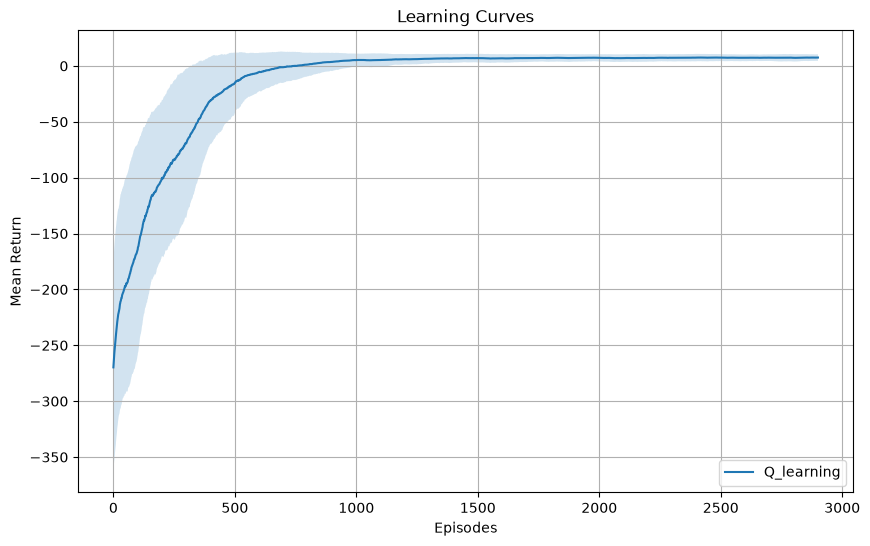

In [11]:
plot_learning_curves(returns)

## 8 · Recording the Trained Agent

We record a GIF of one evaluation episode so we can visually inspect
whether the agent has learned a sensible policy.  
A well-trained Taxi agent should:
1. Navigate to the passenger's location efficiently.  
2. Pick up the passenger.  
3. Drive to the destination and drop off.

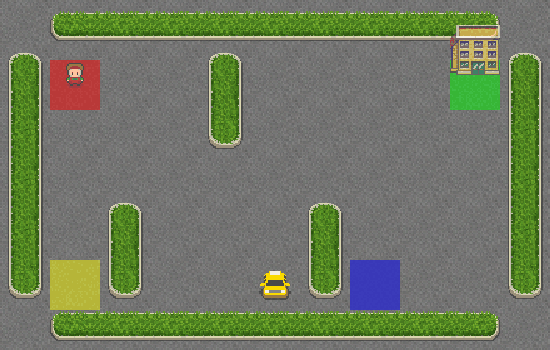

In [15]:

video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)

q_learning_video_path = video_dir / "taxi_q_learning.gif"
avg_reward = q_learning.evaluate_policy(save_video=True, video_dir=str(q_learning_video_path))

display(Image(filename=str(q_learning_video_path)))
